# 🎓 Week 04: FIR & IIR Filters

## 🧠 Learning Objectives
- Understand the difference between FIR and IIR filters
- Design and implement low-pass and high-pass filters
- Visualize filter characteristics using `scipy.signal`
- Evaluate and interpret frequency and phase responses


## 📘 FIR vs IIR – Conceptual Overview

| Feature        | FIR Filter                            | IIR Filter                          |
|----------------|----------------------------------------|-------------------------------------|
| Impulse Response | Finite (eventually becomes 0)         | Infinite (theoretically never ends) |
| Stability      | Always stable                          | Can be unstable                     |
| Phase Response | Can be linear                          | Generally nonlinear                 |
| Design Flexibility | Easier for linear phase             | Requires more care                  |
| Efficiency     | May require higher order               | More efficient for sharp cutoff     |


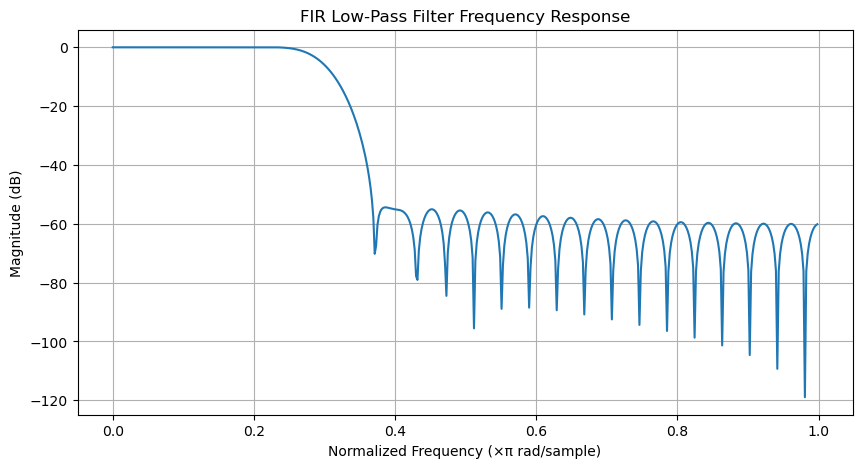

In [1]:
# ⚙️ FIR Low-Pass Filter
from scipy.signal import firwin, freqz
import numpy as np
import matplotlib.pyplot as plt

# Design parameters
numtaps = 51
cutoff = 0.3  # Normalized cutoff frequency (0 to 1, where 1 is Nyquist)

# FIR design
fir_coeff = firwin(numtaps, cutoff)

# Frequency response
w, h = freqz(fir_coeff)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(w / np.pi, 20 * np.log10(abs(h)))
plt.title("FIR Low-Pass Filter Frequency Response")
plt.xlabel("Normalized Frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.show()

/var/folders/sz/wb36d72s4fl4h2g0s14chb840000gn/T/ipykernel_34940/4023540665.py:16: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w / np.pi, 20 * np.log10(abs(h)))


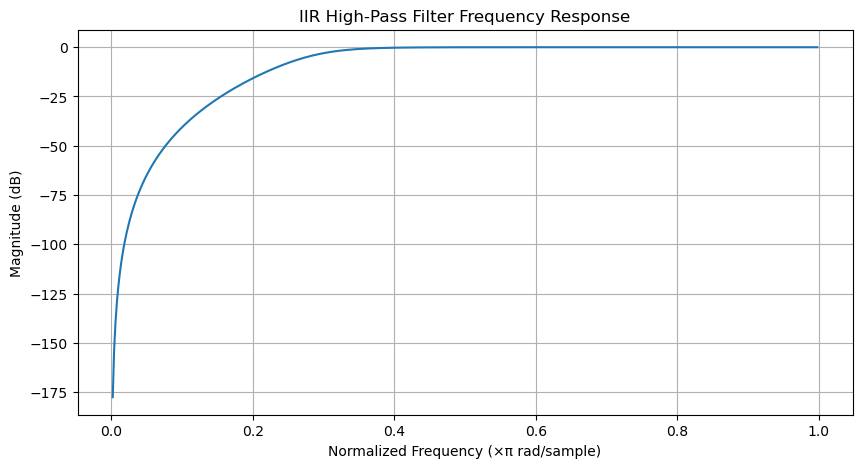

In [2]:
# ⚙️ IIR High-Pass Filter
from scipy.signal import butter, freqz

# Design parameters
order = 4
cutoff = 0.3

# IIR design
b, a = butter(order, cutoff, btype='high', analog=False)

# Frequency response
w, h = freqz(b, a)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(w / np.pi, 20 * np.log10(abs(h)))
plt.title("IIR High-Pass Filter Frequency Response")
plt.xlabel("Normalized Frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.show()

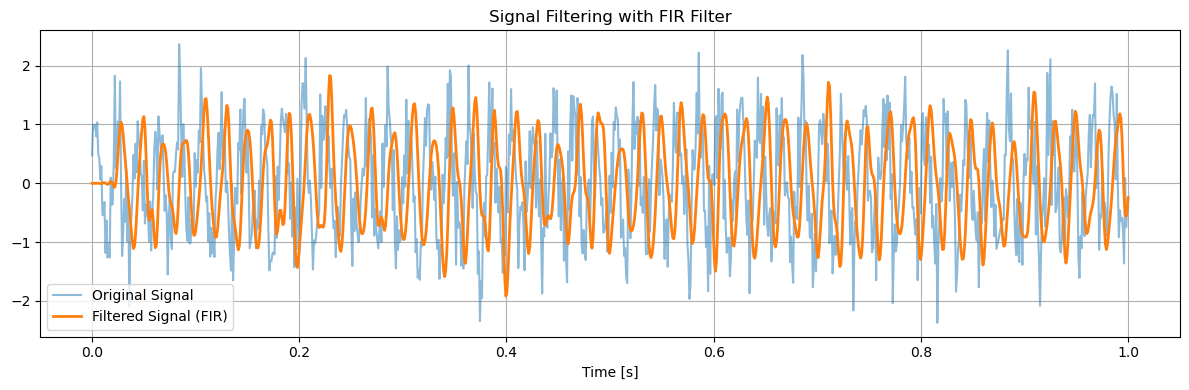

In [3]:
# 🔍 Filter Application Example
from scipy.signal import lfilter

# Example signal: noisy sinusoid
fs = 1000
t = np.linspace(0, 1.0, fs)
signal = np.sin(2 * np.pi * 50 * t) + 0.5 * np.random.randn(t.size)

# Apply FIR low-pass
filtered_signal = lfilter(fir_coeff, 1.0, signal)

# Plot original and filtered signals
plt.figure(figsize=(12, 4))
plt.plot(t, signal, label='Original Signal', alpha=0.5)
plt.plot(t, filtered_signal, label='Filtered Signal (FIR)', linewidth=2)
plt.legend()
plt.title("Signal Filtering with FIR Filter")
plt.xlabel("Time [s]")
plt.grid()
plt.tight_layout()
plt.show()

/var/folders/sz/wb36d72s4fl4h2g0s14chb840000gn/T/ipykernel_34940/481869718.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w / np.pi, 20 * np.log10(abs(h)))


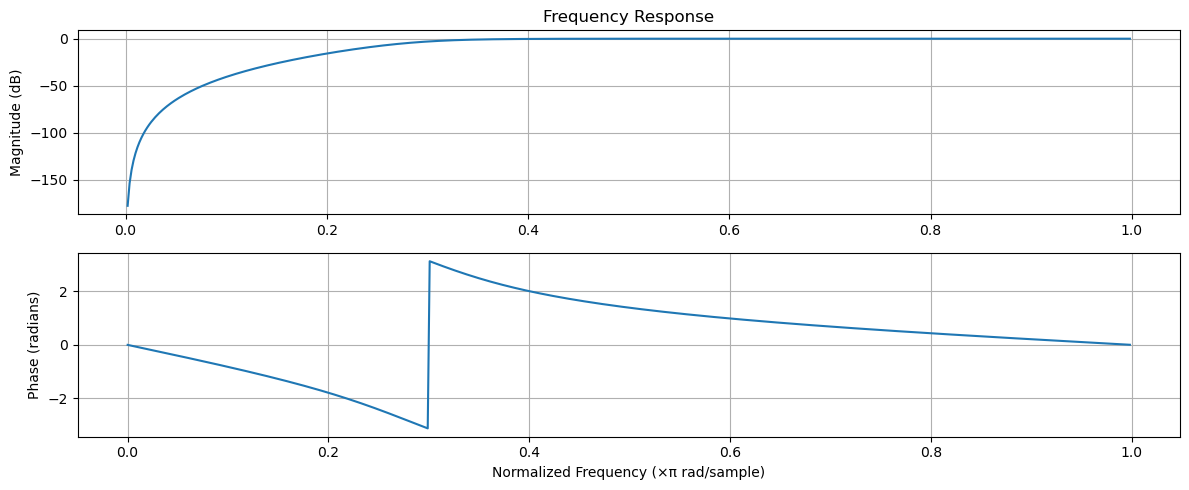

In [4]:
# 📈 Frequency and Phase Response
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1)
plt.plot(w / np.pi, 20 * np.log10(abs(h)))
plt.title("Frequency Response")
plt.ylabel("Magnitude (dB)")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(w / np.pi, np.angle(h))
plt.ylabel("Phase (radians)")
plt.xlabel("Normalized Frequency (×π rad/sample)")
plt.grid()

plt.tight_layout()
plt.show()